In [52]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import random

In [2]:
img = mpimg.imread("src/map_krikket.png")

## Visualisation de la carte
_____

In [3]:
img_centree = img * 255 - 93

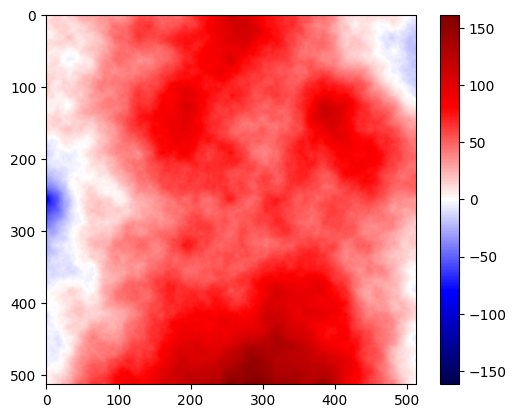

In [6]:
fig, ax = plt.subplots()
image = ax.imshow(img_centree, cmap="seismic", vmin=-162, vmax=162)
plt.colorbar(image, ax=ax)
plt.show()

## Fonctions
______

In [49]:
def check_border_limit(p1: tuple, img: np.ndarray) -> bool:
    """
    Fonction qui vérifie que les coordonnées du point ``p1`` sont bien dans le tableau ``img``.

    Args:
        p1 (tuple) : les coordonnées du point dont on souhaite vérifier qu'il est dans le tableau.
        img (numpy.ndarray) : le tableau.

    Returns:
        bool : True si p1 est dans img, False autrement.
    """
    if p1[0] > img.shape[0]-1 or p1[1] > img.shape[1]-1:
        return False
    return True

In [50]:
def compute_denivele_between_two_points(p1: tuple, p2: tuple, img: np.ndarray) -> float:
    """
    Fonction qui calcule le dénivelé entre les points ``p1`` et ``p2`` du tableau ``img``.

    Args:
        p1 (tuple) : les coordonnées du point p1.
        p2 (tuple) : les coordonnées du point p2.
        img (numpy.ndarray) : le tableau.
    """
    if not check_border_limit(p1, img) or not check_border_limit(p2, img):
        return False
    return float(img[p2[0]][p2[1]] - img[p1[0]][p1[1]])

In [51]:
p1 = (0, 0)
p2 = (512, 512)

In [48]:
compute_denivele_between_two_points(p1, p2, img_centree)

0.0

In [30]:
img_centree.shape

(513, 513)

In [37]:
type(img_centree)

numpy.ndarray

In [73]:
def choice_direction_by_looking_n_forward(p1: tuple, img: np.ndarray, n: int):

    # On vérifie que le point courant est bien dans l'image (c'est censé être toujours le cas mais on vérifie quand même).
    if not check_border_limit(p1=p1, img=img):
        raise ValueError("Le point courant est hors de l'image.")

    n_col = img.shape[1]
    n_row = img.shape[0]

    # On vérifie si on est sur un bord:
    # - si on est sur la dernière colonne (tout à droite), on est obligé de descendre.
    # - si on est sur la dernière ligne (tout en bas), on est obligé d'aller à droite.
    # - si on est à la fois sur la dernière colonne ET la dernière ligne (sur le point B), on continue de retourner le point B.
    if p1[0] == n_row-1 and p1[1] == n_col-1:
        return p1
    elif p1[0] == n_row-1:
        return (p1[0], p1[1]+1)
    elif p1[1] == n_col-1:
        return (p1[0]+1, p1[1])

    # Pour pouvoir regarder n cases sur la droite, il faut qu'il y ait au moins n case à droite du point courant (idem vers le bas).
    if min(n_row - p1[0], n_col - p1[1]) < n:
        n = min(n_row - p1[0], n_col - p1[1])

    # =============================================
    # Calcul du gradient des n cases vers la droite
    # =============================================

    right_denivele = 0

    for i in range(1, n+1):
        delta = compute_denivele_between_two_points(p1=p1, p2=(p1[0], p1[1]+i), img=img)
        if delta > 0:
            right_denivele += delta

    # ==========================================
    # Calcul du gradient des n cases vers le bas
    # ==========================================

    bottom_denivele = 0

    for i in range(1, n+1):
        delta = compute_denivele_between_two_points(p1=p1, p2=(p1[0]+1, p1[1]), img=img)
        if delta > 0:
            bottom_denivele += delta

    # =================
    # Prise de décision
    # =================

    if right_denivele < bottom_denivele:
        return (p1[0], p1[1]+1)

    elif right_denivele > bottom_denivele:
        return (p1[0]+1, p1[1])

    # En cas d'égalité du gradient droite/bas, on prends une décision aléatoire.
    elif right_denivele == bottom_denivele:
        return random.choice([(p1[0], p1[1]+1), (p1[0]+1, p1[1])])


In [74]:
choice_direction_by_looking_n_forward(p1=(0,0), img=img_centree, n=1)

(1, 0)

### Test de la fonction de prise de décision
____

#### Test 01

In [136]:
img_test_01 = np.array([[100, 150, 255],[160, 255, 255], [120, 180, 100]])

In [137]:
position = (0,0)
path_n1 = []

for i in range(10):
    path_n1.append(position)
    position = choice_direction_by_looking_n_forward(p1=position, img=img_test_01, n=1)

In [138]:
position = (0,0)
path_n2 = []

for i in range(10):
    path_n2.append(position)
    position = choice_direction_by_looking_n_forward(p1=position, img=img_test_01, n=2)

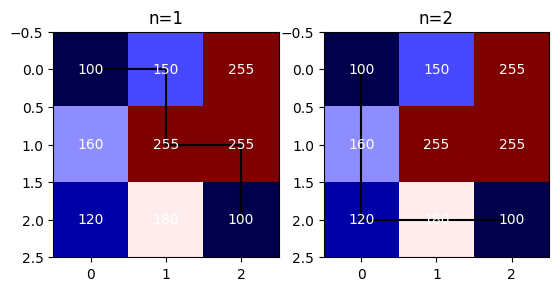

In [139]:
fig, ax = plt.subplots(nrows=1, ncols=2)
image = ax[0].imshow(img_test_01, cmap="seismic", vmin=100, vmax=255)
ax[0].plot([i[1] for i in path_n1], [i[0] for i in path_n1], color="k")
ax[0].set_title("n=1")

image = ax[1].imshow(img_test_01, cmap="seismic", vmin=100, vmax=255)
ax[1].plot([i[1] for i in path_n2], [i[0] for i in path_n2], color="k")
ax[1].set_title("n=2")

for i in range(len(path_n1[0])+1):
    for j in range(len(path_n1[1])+1):
        text = ax[0].text(j, i, img_test_01[i, j],
                       ha="center", va="center", color="w")
for i in range(len(path_n1[0])+1):
    for j in range(len(path_n1[1])+1):
        text = ax[1].text(j, i, img_test_01[i, j],
                       ha="center", va="center", color="w")

#plt.colorbar(image, ax=ax)

plt.show()

En regardant seulement 1 case devant soit, on préfère passer de 100 à 150 que de 100 à 160.
Pourtant, en partant sur le 150, on se retrouve "piégé" au milieu de 255.

En allant sur le 160 dès le début, on a un meilleur chemin, trouvé en regardant 2 cases devant soit à chaque décision au lieu de 1.

#### Test 02

In [141]:
img_test_02 = np.array([[130, 127],[154, 207], [100, 148]])

In [142]:
img_test_02

array([[130, 127],
       [154, 207],
       [100, 148]])

In [150]:
position = (0,0)
path_n1 = []

for i in range(10):
    path_n1.append(position)
    position = choice_direction_by_looking_n_forward(p1=position, img=img_test_02, n=1)

In [151]:
position = (0,0)
path_n2 = []

for i in range(10):
    path_n2.append(position)
    position = choice_direction_by_looking_n_forward(p1=position, img=img_test_02, n=2)

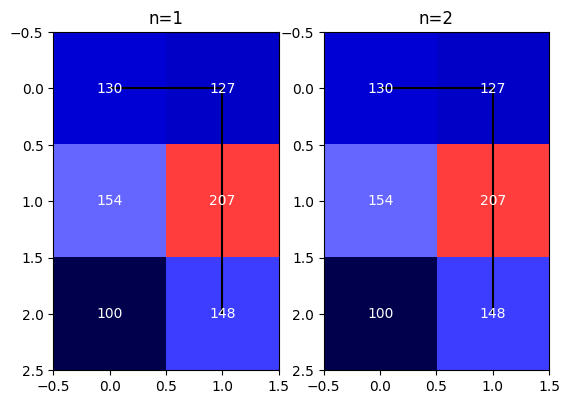

In [158]:
fig, ax = plt.subplots(nrows=1, ncols=2)
image = ax[0].imshow(img_test_02, cmap="seismic", vmin=100, vmax=255)
ax[0].plot([i[1] for i in path_n1], [i[0] for i in path_n1], color="k")
ax[0].set_title("n=1")

image = ax[1].imshow(img_test_02, cmap="seismic", vmin=100, vmax=255)
ax[1].plot([i[1] for i in path_n2], [i[0] for i in path_n2], color="k")
ax[1].set_title("n=2")

for i in range(len(path_n1[0])+1):
    for j in range(len(path_n1[1])):
        text = ax[0].text(j, i, img_test_02[i, j],
                       ha="center", va="center", color="w")
for i in range(len(path_n1[0])+1):
    for j in range(len(path_n1[1])):
        text = ax[1].text(j, i, img_test_02[i, j],
                       ha="center", va="center", color="w")

#plt.colorbar(image, ax=ax)

plt.show()

On voit que l'algorithme de prise de décision n'est pas efficace lorsque l'on arrive au bord.
En regardant 2 cases vers la droite, l'argo prends la décision de n'en regarder qu'une seule puisqu'il n'y en a pas 2 dispo.
Cela revient à avoir n=1.

Or, avec n=1 dans cette situation, on préfère partir à droite et on se retrouve "piégé" à devoir aller sur le 207.

Le problème est peut être qu'on ne prends pas en compte la case diagonale ?